In [1]:
# Run this cell to set up packages for lecture.
import pandas as pd
import numpy as np
from pathlib import Path

import matplotlib.pyplot as plt

path = 'lectures/lec07'
if not Path('data').exists():
    !wget -q -O /content/course.zip https://github.com/dsc-courses/cosmos-ml-cluster-2026/archive/refs/heads/main.zip
    !unzip -q -o /content/course.zip "cosmos-ml-cluster-2026-main/{path}/data/*" -d /content/course-assets
    !cp -R /content/course-assets/cosmos-ml-cluster-2026-main/{path}/data .

plt.style.use('seaborn-v0_8-colorblind')
plt.rcParams.update({
    'figure.figsize': (10, 5),
    'axes.titlesize': 14,
    'axes.titleweight': 'bold',
    'axes.labelsize': 12,
    'axes.labelweight': 'bold',
    'axes.linewidth': 1.5,
    'grid.color': '#999999',
    'grid.alpha': 0.5,
    'font.weight': 'bold',
    'legend.fontsize': 11,
})

pd.set_option('display.max_rows', 8)
pd.set_option('display.max_columns', 10)
pd.set_option('display.precision', 2)


# Lecture 7 - k-Nearest Neighbors

## COSMOS ML Cluster 2026

### Agenda

- What kinds of machine-learning tasks are there?
- Classification versus regression.
- A simple nearest-neighbor classifier.
- Decision boundaries and k-nearest neighbors.
- Train/test splits and evaluating a classifier.

## Can a computer learn from examples?

Spotify knows some songs' genres and their audio features.

> Can we use those examples to predict the genre of a new song?

Today, we will predict one of three genres: **classical**, **hip-hop**, or **rock**.

## Three broad kinds of machine learning

| Kind of task | Main idea | Example |
| --- | --- | --- |
| **Supervised learning** | Learn from examples whose answers are known. | Predict a song's genre from songs with known genres. |
| **Unsupervised learning** | Look for structure when answers are not supplied. | Group similar songs into clusters. |
| **Reinforcement learning** | Learn actions from rewards and penalties. | Learn which moves help an agent win a game. |

We will study **supervised learning** today.

### Two types of supervised learning

| Task | What is predicted? | Spotify example |
| --- | --- | --- |
| **Regression** | A number | Predict a song's popularity score. |
| **Classification** | A category | Predict a song's genre. |

The kind of task depends on the answer we want to predict—not on whether the **features** contain numbers.

## The Spotify data

Each row is one song. The measurements we use to make a prediction are called **features**. The answer we want to predict is the **target**; in classification, we also call it a **label**.

In [2]:
songs = pd.read_csv('data/spotify-three-genres.csv').rename(columns={'track_genre': 'genre'})
songs


,track_id,artists,track_name,danceability,energy,...,acousticness,instrumentalness,liveness,valence,genre
0,0fMditvyHKtvP0Wda7b3Wt,Wolfgang Amadeus Mozart;Danielle Laval,12 Variations on ‘La belle Françoise’ in E fla...,0.39,1.13e-01,...,0.99,8.42e-01,0.14,0.74,classical
1,0JAzwrikHrPWVK02ANRkHl,Wolfgang Amadeus Mozart;Giuseppe Greco,"Piano Sonata No. 17 in B-Flat Major, K. 570: I...",0.45,8.84e-03,...,0.99,9.13e-01,0.09,0.22,classical
2,7FM43USRDOLBicvp6Zvnjk,Wolfgang Amadeus Mozart;I Musici;Pina Carmirelli,"Serenade in G, K.525: 1. Allegro",0.45,2.47e-01,...,0.87,8.69e-01,0.22,0.62,classical
3,4N9wT4gXdCIVIoyYrGQ5ms,Wolfgang Amadeus Mozart;Wiener Mozart Ensemble...,"Contredanse in E flat, K.607 ""Il Trionfo delle...",0.64,2.03e-01,...,0.96,3.26e-01,0.17,0.72,classical
...,...,...,...,...,...,...,...,...,...,...,...
2795,3UlFXr9WI8uXEYqptzPqC6,Bastille,Revolution,0.63,7.55e-01,...,0.08,0.00e+00,0.14,0.78,rock
2796,1Gige3ZwDzFN55FSoim5Kv,The Beach Boys,Good Vibrations - Remastered 2001,0.40,5.46e-01,...,0.36,1.20e-04,0.12,0.35,rock
2797,2LawezPeJhN4AWuSB0GtAU,Creedence Clearwater Revival,Have You Ever Seen The Rain,0.74,6.97e-01,...,0.07,2.28e-05,0.13,0.77,rock
2798,2qHiyBpxyOXnRGG3t2iE96,Phillip Phillips,"Gone, Gone, Gone",0.66,6.42e-01,...,0.13,0.00e+00,0.11,0.50,rock


In [3]:
songs.columns

Index(['track_id', 'artists', 'track_name', 'danceability', 'energy',
       'speechiness', 'acousticness', 'instrumentalness', 'liveness',
       'valence', 'genre'],
      dtype='str')

In [4]:
songs.groupby('genre').size()

genre
classical    933
hip-hop      933
rock         933
dtype: int64

### Listen to one song from each genre

Before looking at the numbers, listen to a familiar example from each genre. The players below use Spotify's web embed player.


In [5]:
from IPython.display import HTML, display

def play_song(track_id, title):
    # Display Spotify's web embed player for one track.
    display(HTML(f'''<p><strong>{title}</strong></p>
    <iframe style="border-radius:12px" src="https://open.spotify.com/embed/track/{track_id}?utm_source=generator"
    width="100%" height="152" frameBorder="0" allowfullscreen=""
    allow="autoplay; clipboard-write; encrypted-media; fullscreen; picture-in-picture" loading="lazy"></iframe>'''))

play_song('0KMayG55Y3QCYK2Yxq7qj7', 'Classical: Beethoven — Moonlight Sonata')
play_song('1v7L65Lzy0j0vdpRjJewt1', 'Hip-hop: Eminem — Lose Yourself')
play_song('4u7EnebtmKWzUH433cf5Qv', 'Rock: Queen — Bohemian Rhapsody')


### Predicting with two features

We will start with two features, both between 0 and 1:

- **speechiness**: how much the recording resembles spoken words.
- **acousticness**: how likely the song is acoustic.

A classifier can eventually use more than two features. We begin with two because we can draw them on a scatterplot.

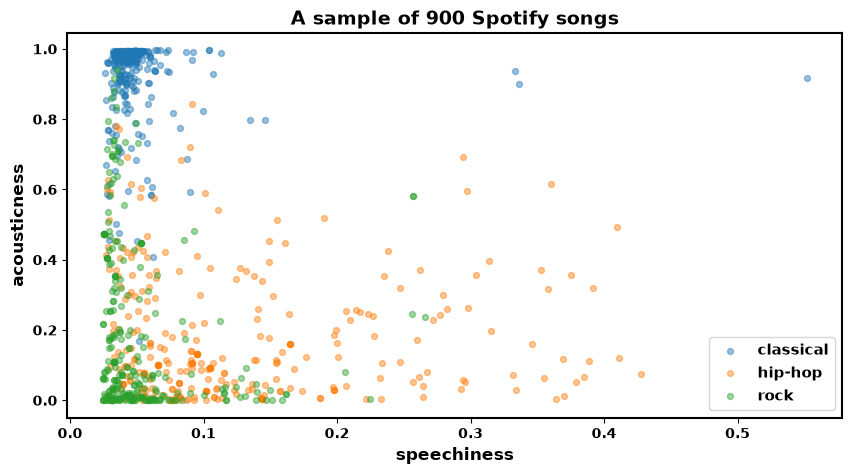

In [6]:
features = ['speechiness', 'acousticness']
genres = ['classical', 'hip-hop', 'rock']
colors = {'classical': 'tab:blue', 'hip-hop': 'tab:orange', 'rock': 'tab:green'}

def plot_songs(data, ax=None, title='Spotify songs'):
    if ax is None:
        _, ax = plt.subplots()
    for genre in genres:
        points = data[data['genre'] == genre]
        ax.scatter(points['speechiness'], points['acousticness'],
                   label=genre, color=colors[genre], alpha=0.45, s=18)
    ax.set(xlabel='speechiness', ylabel='acousticness', title=title)
    ax.legend()
    return ax

plot_songs(songs.sample(900, random_state=42), title='A sample of 900 Spotify songs');

### Hear three different regions of the plot

These songs give us a feel for the three combinations of the two features.


In [7]:
play_song('0ROMalDdNg3L2HoZP4qFyJ',
          'High acousticness (0.818), low speechiness (0.0423): Vivaldi — The Four Seasons: Winter')
play_song('1v7L65Lzy0j0vdpRjJewt1',
          'Low acousticness (0.00921), high speechiness (0.264): Eminem — Lose Yourself')
play_song('2WfaOiMkCvy7F5fcp2zZ8L',
          'Low acousticness (0.018), low speechiness (0.054): a-ha — Take on Me')


### What patterns do you notice?

- Are songs from the same genre near one another?
- Where do the genres overlap?
- How might we use nearby labeled songs to predict a new song's genre?

## A very simple classifier: 1-nearest neighbor

For a new song:

1. Find the **one closest** labeled song.
2. Predict that song's genre.

This is called **1-nearest neighbor**, or **1-NN**.

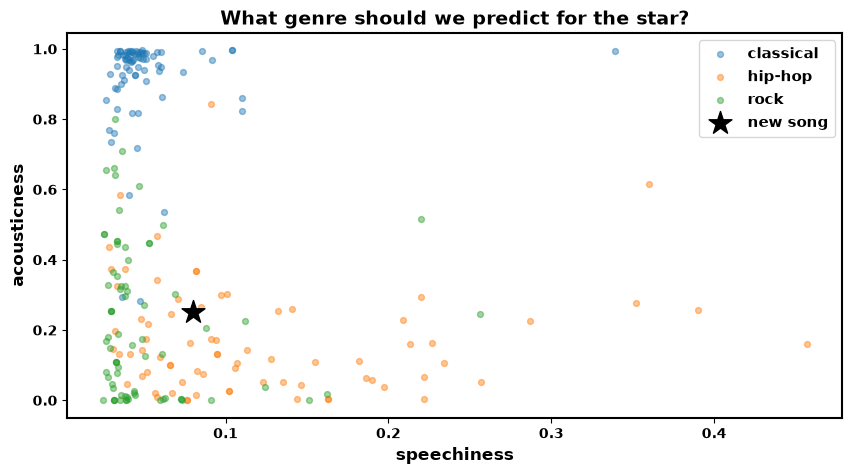

In [8]:
# We use a small group of songs so that the neighbors are easy to inspect.
demo_songs = (songs.groupby('genre', group_keys=False)
                   .sample(75, random_state=7)
                   .reset_index(drop=True))

mystery_song = pd.Series({'speechiness': 0.08, 'acousticness': 0.25})

ax = plot_songs(demo_songs, title='What genre should we predict for the star?')
ax.scatter(mystery_song['speechiness'], mystery_song['acousticness'],
           marker='*', s=300, color='black', label='new song')
ax.legend();

### Measuring closeness

We will use ordinary straight-line distance. For two points $(x_1, y_1)$ and $(x_2, y_2)$:

$$
distance = \sqrt{(x_1 - x_2)^2 + (y_1 - y_2)^2)}.
$$

Here, the two coordinates are `speechiness` and `acousticness`.

In [9]:
def distance(song_a, song_b):
    """Return the distance between two songs using our two features."""
    return np.sqrt(((song_a[features] - song_b[features]) ** 2).sum())

distance(demo_songs.iloc[0], mystery_song)

np.float64(0.5689929349297758)

In [10]:
def predict_1nn(new_song, labeled_songs):
    """Predict a genre using the genre of the closest labeled song."""
    distances = labeled_songs.apply(lambda song: distance(song, new_song), axis=1)
    closest_song = labeled_songs.loc[distances.idxmin()]
    return closest_song['genre']

predict_1nn(mystery_song, demo_songs)

'hip-hop'

In [11]:
neighbors = demo_songs.copy()
neighbors['distance'] = neighbors.apply(lambda song: distance(song, mystery_song), axis=1)
neighbors.nsmallest(5, 'distance')[['track_name', 'artists', 'genre', 'distance']]

,track_name,artists,genre,distance
125,Woh Kisna Hai,Sukhwinder Singh;Ayesha Darbar;S. P. Sailaja,hip-hop,0.01
138,Brown Rang,Yo Yo Honey Singh,hip-hop,0.02
120,Tu Cuerpo Me Arrebata,Don Omar;Trebol Clan,hip-hop,0.04
163,Bohemian Rhapsody - Remastered 2011,Queen,rock,0.04
187,Tequila,Juanes;Christian Nodal,rock,0.04


### Listen to two nearby examples

The closest neighbor is hip-hop. We can also compare it with the closest rock song.


In [12]:
closest_neighbor = neighbors.nsmallest(1, 'distance').iloc[0]
closest_rock_neighbor = neighbors[neighbors['genre'].eq('rock')].nsmallest(1, 'distance').iloc[0]

display(pd.DataFrame([closest_neighbor, closest_rock_neighbor])[
    ['track_name', 'artists', 'genre', 'distance']
])
play_song(closest_neighbor['track_id'],
          f"Closest neighbor ({closest_neighbor['genre']}): {closest_neighbor['track_name']}")
play_song(closest_rock_neighbor['track_id'],
          f"Closest rock neighbor: {closest_rock_neighbor['track_name']}")


,track_name,artists,genre,distance
125,Woh Kisna Hai,Sukhwinder Singh;Ayesha Darbar;S. P. Sailaja,hip-hop,0.01
163,Bohemian Rhapsody - Remastered 2011,Queen,rock,0.04


## Decision boundaries

A **decision boundary** is a dividing line where a classifier changes its predicted genre.

Imagine predicting the genre at every possible point on this scatterplot. The colored regions show what the classifier would predict.

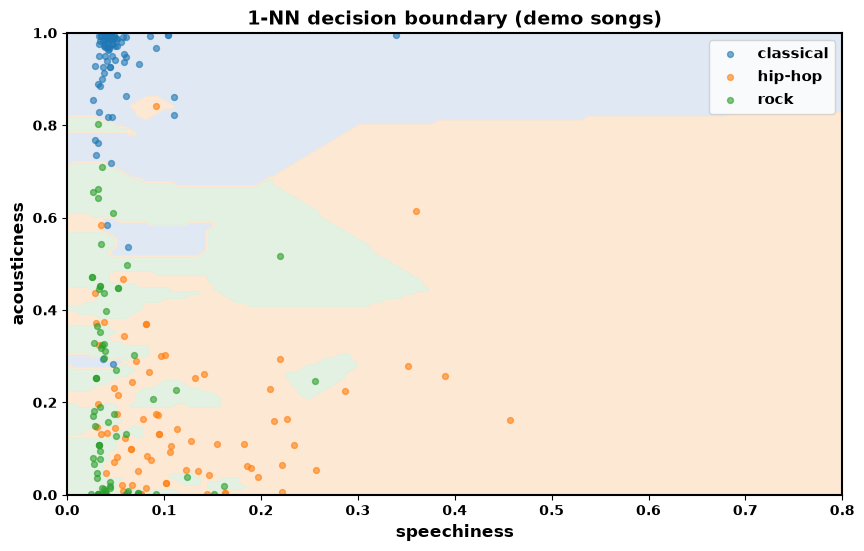

In [13]:
def plot_handwritten_1nn_boundary(labeled_songs, ax):
    x_values = np.linspace(0, 0.8, 120)
    y_values = np.linspace(0, 1, 120)
    xx, yy = np.meshgrid(x_values, y_values)
    grid = np.column_stack([xx.ravel(), yy.ravel()])
    reference_points = labeled_songs[features].to_numpy()

    squared_distances = ((grid[:, np.newaxis, :] - reference_points[np.newaxis, :, :]) ** 2).sum(axis=2)
    closest_indices = squared_distances.argmin(axis=1)
    predicted = labeled_songs['genre'].to_numpy()[closest_indices]
    region_codes = pd.Categorical(predicted, categories=genres).codes.reshape(xx.shape)

    ax.contourf(xx, yy, region_codes, levels=[-0.5, 0.5, 1.5, 2.5],
                colors=['#dce6f2', '#fde6cf', '#dff0df'], alpha=0.9)
    for genre in genres:
        points = labeled_songs[labeled_songs['genre'].eq(genre)]
        ax.scatter(points['speechiness'], points['acousticness'], color=colors[genre],
                   s=18, alpha=0.6, label=genre)
    ax.set(xlabel='speechiness', ylabel='acousticness',
           title='1-NN decision boundary (demo songs)')
    ax.legend()

_, ax = plt.subplots(figsize=(10, 6))
plot_handwritten_1nn_boundary(demo_songs, ax)


### Why might 1-NN be a problem?

1-NN is very sensitive to individual songs:

- Its decision boundary can be jagged.
- A single unusual song controls the region around it.
- Two very similar new songs can have different predictions.

1-NN is a useful baseline, but we may not want every single song to have so much influence.

## k-nearest neighbors

Instead of trusting one neighbor, **k-NN** finds the $k$ closest labeled songs and lets them vote.

For example, if the five nearest songs contain three hip-hop songs, one rock song, and one classical song, we predict **hip-hop**.

In [14]:
neighbors.nsmallest(5, 'distance')['genre'].value_counts()

genre
hip-hop    3
rock       2
Name: count, dtype: int64

### Choosing $k$

- A small $k$ is more affected by individual songs.
- A larger $k$ produces smoother predictions.
- A very large $k$ can ignore useful local patterns.

We will use $k = 5$ today. We are **not** trying to find the best value of $k$ yet.

## scikit-learn

**scikit-learn** is a Python library with ready-made tools for common machine-learning tasks. We will use it to split data, fit classifiers, make predictions, and measure their accuracy.

It is useful once we have a clear prediction task and prepared numerical features. It cannot decide which question matters, repair poor labels or data, or tell us whether a model's predictions are appropriate to use. Those remain human decisions.


In [15]:
from sklearn.metrics import ConfusionMatrixDisplay, accuracy_score
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier


## Train/test split

A model can look impressive if we only ask it about songs it has already seen. Instead, we reserve some songs until the end.

| Set | Purpose |
| --- | --- |
| **Training set** | Songs the classifier may use to make its rule. |
| **Test set** | Songs kept aside to evaluate predictions on unseen songs. |

In [16]:
X = songs[features]
y = songs['genre']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f'Training songs: {len(X_train):,}')
print(f'Test songs:     {len(X_test):,}')
print('\nGenres in the training set:')
print(y_train.value_counts().sort_index())
print('\nGenres in the test set:')
print(y_test.value_counts().sort_index())

Training songs: 2,239
Test songs:     560

Genres in the training set:
genre
classical    753
hip-hop      738
rock         748
Name: count, dtype: int64

Genres in the test set:
genre
classical    180
hip-hop      195
rock         185
Name: count, dtype: int64


## k-NN in scikit-learn

`scikit-learn` lets us apply the same nearest-neighbor idea to the training data.

In [17]:
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)

test_predictions = knn.predict(X_test)
test_predictions[:10]

array(['hip-hop', 'classical', 'rock', 'hip-hop', 'hip-hop', 'rock',
       'rock', 'rock', 'classical', 'hip-hop'], dtype=object)

- `X_train` contains the feature values for the songs the classifier may learn from.
- `y_train` contains their known genres.
- `fit` gives the classifier the labeled training songs.
- `predict(X_test)` asks for predictions on songs it did not use for learning.

## Training and test error

**Error** is the fraction of predictions that are incorrect. Training error measures songs the classifier has already seen; test error is computed on songs that the classifier didn't use for training.


In [18]:
train_predictions = knn.predict(X_train)
test_predictions = knn.predict(X_test)

five_nn_training_error = 1 - accuracy_score(y_train, train_predictions)
five_nn_test_error = 1 - accuracy_score(y_test, test_predictions)

print(f'5-NN training error: {five_nn_training_error:.1%}')
print(f'5-NN test error:     {five_nn_test_error:.1%}')


5-NN training error: 13.7%
5-NN test error:     17.5%


In [19]:
test_results = X_test.copy()
test_results['actual_genre'] = y_test
test_results['predicted_genre'] = test_predictions
test_results['correct'] = test_results['actual_genre'] == test_results['predicted_genre']
test_results.query('not correct').head(10)

,speechiness,acousticness,actual_genre,predicted_genre,correct
1613,0.05,0.44,hip-hop,rock,False
1395,0.03,0.59,hip-hop,classical,False
321,0.06,0.63,classical,hip-hop,False
1099,0.30,0.60,hip-hop,rock,False
...,...,...,...,...,...
831,0.09,0.69,classical,rock,False
1241,0.04,0.03,hip-hop,rock,False
1992,0.09,0.46,rock,hip-hop,False
2641,0.05,0.43,rock,hip-hop,False


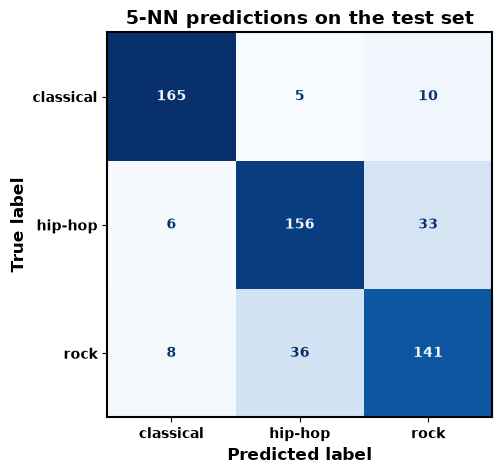

In [20]:
ConfusionMatrixDisplay.from_predictions(y_test, test_predictions, cmap='Blues', colorbar=False)
plt.title('5-NN predictions on the test set');

### Concept Check

Compared with 5-NN, do you expect 1-NN's **training error** to be higher or lower? What about its **test error**? Make a numerical guess for both errors before running the next cell.

*Hint: when 1-NN predicts the training songs, what is each song's closest training neighbor?*


In [21]:
one_nn = KNeighborsClassifier(n_neighbors=1).fit(X_train, y_train)
one_nn_training_error = 1 - one_nn.score(X_train, y_train)
one_nn_test_error = 1 - one_nn.score(X_test, y_test)

print(f'1-NN training error: {one_nn_training_error:.1%}')
print(f'1-NN test error:     {one_nn_test_error:.1%}')
print()
print('Reflection:')
print('1-NN has lower training error because each training song is its own closest neighbor.')
if one_nn_test_error > five_nn_test_error:
    print('Its test error is higher than 5-NN’s, so fitting every training song perfectly did not generalize as well.')
elif one_nn_test_error < five_nn_test_error:
    print('Its test error is lower than 5-NN’s for this split, even though it fits the training data more closely.')
else:
    print('Its test error matches 5-NN’s for this split, despite fitting the training data more closely.')


1-NN training error: 0.0%
1-NN test error:     17.0%

Reflection:
1-NN has lower training error because each training song is its own closest neighbor.
Its test error is lower than 5-NN’s for this split, even though it fits the training data more closely.


### Interpreting mistakes

Mistakes are useful information. In this dataset, hip-hop and rock songs are often confused with one another. That makes sense: their points overlap more than the classical songs do.

Also, genre labels are not perfect truth—some songs blend genres, and genre labels can be subjective.

## 1-NN versus 5-NN decision boundaries

The `KNeighborsClassifier` with `n_neighbors=1` implements the same rule as our hand-written 1-NN classifier. We use it below to draw both boundaries with the same code.

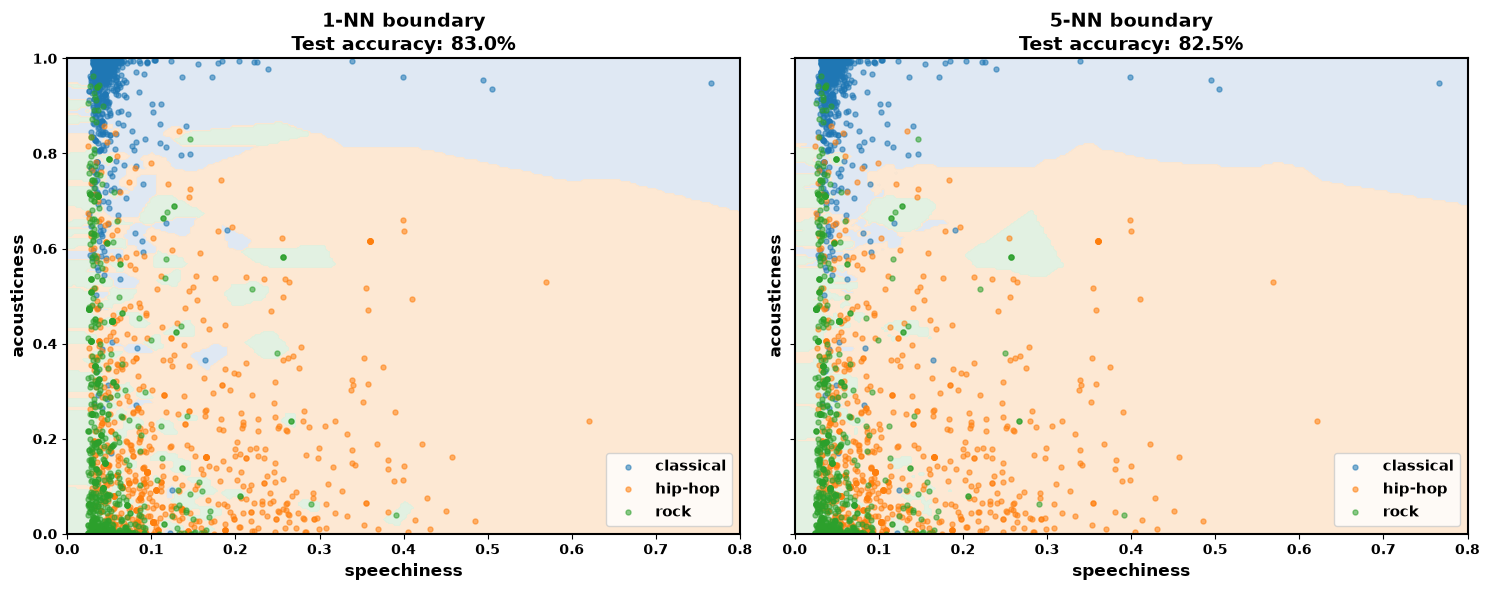

In [22]:
def plot_boundary(model, X_data, y_data, ax, title):
    x_values = np.linspace(0, 0.8, 200)
    y_values = np.linspace(0, 1, 200)
    xx, yy = np.meshgrid(x_values, y_values)
    grid = pd.DataFrame({'speechiness': xx.ravel(), 'acousticness': yy.ravel()})
    predicted = model.predict(grid)
    code = pd.Categorical(predicted, categories=genres).codes.reshape(xx.shape)
    ax.contourf(xx, yy, code, levels=[-0.5, 0.5, 1.5, 2.5],
                colors=['#dce6f2', '#fde6cf', '#dff0df'], alpha=0.9)
    for genre in genres:
        points = X_data[y_data == genre]
        ax.scatter(points['speechiness'], points['acousticness'],
                   color=colors[genre], s=13, alpha=0.55, label=genre)
    ax.set(xlabel='speechiness', ylabel='acousticness', title=title)
    ax.legend()

five_nn = knn

fig, axes = plt.subplots(1, 2, figsize=(15, 6), sharex=True, sharey=True)
plot_boundary(one_nn, X_train, y_train, axes[0],
              f'1-NN boundary\nTest accuracy: {one_nn.score(X_test, y_test):.1%}')
plot_boundary(five_nn, X_train, y_train, axes[1],
              f'5-NN boundary\nTest accuracy: {five_nn.score(X_test, y_test):.1%}')
plt.tight_layout()

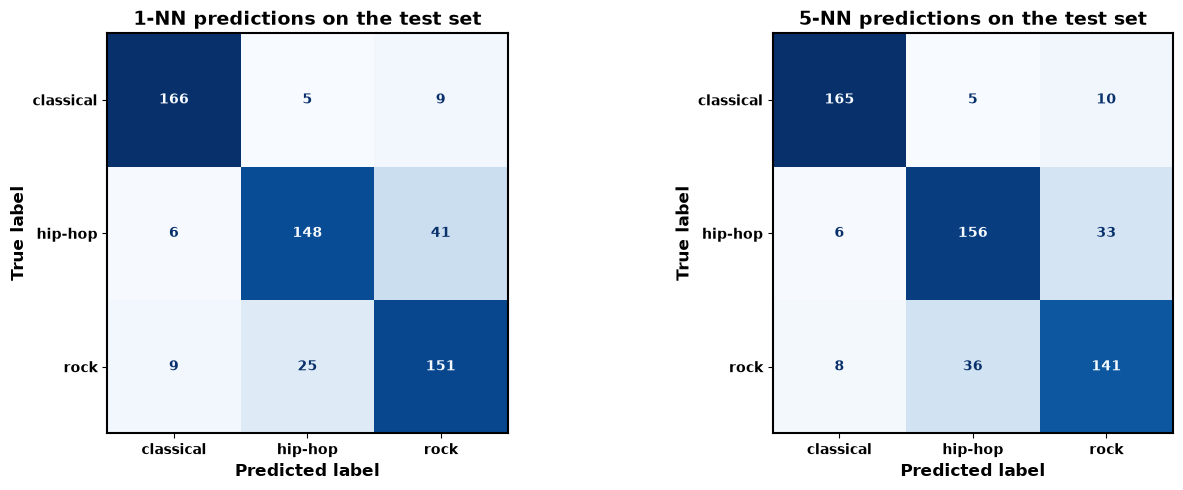

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for model, name, ax in [(one_nn, '1-NN', axes[0]), (five_nn, '5-NN', axes[1])]:
    ConfusionMatrixDisplay.from_predictions(
        y_test, model.predict(X_test), display_labels=genres,
        cmap='Blues', colorbar=False, ax=ax
    )
    ax.set_title(f'{name} predictions on the test set')

plt.tight_layout()

## Takeaways

- **Supervised learning** uses examples with known answers.
- **Classification** predicts categories; **regression** predicts numbers.
- 1-NN copies the closest labeled example's genre.
- k-NN lets several nearby examples vote.
- A **decision boundary** shows where a classifier's prediction changes.
- A **train/test split** lets us evaluate predictions on songs the model did not use for learning.